In [ ]:
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=6d50d4c119910405b3b19cbc0c8617361b2987ca6277aca9264ff9c2da330ff2
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
dataset=pd.read_csv('/content/Market_Basket.csv',header=None)
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dataset.shape

(7501, 20)

In [ ]:
transactions=[]
for i in range(0,7501):
  transactions.append([str(dataset.values[i,j])for j in range(0,20)])

In [ ]:
transactions

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers',
  'meatballs',
  'eggs',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['chutney',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['turkey',
  'avocado',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['mineral water',
  'milk',
  'energy bar',
  'whole wheat rice',
  'green tea',
  'nan',
  'nan',
  'nan',
 

In [ ]:
#Apply Apriori algorithm
from apyori import apriori
rules=apriori(transactions=transactions,min_support=0.005,min_confidence=0.2,min_lift=3,min_length=2,max_length=3)
results=list(rules)

In [ ]:
results

[RelationRecord(items=frozenset({'escalope', 'mushroom cream sauce'}), support=0.005732568990801226, ordered_statistics=[OrderedStatistic(items_base=frozenset({'mushroom cream sauce'}), items_add=frozenset({'escalope'}), confidence=0.3006993006993007, lift=3.790832696715049)]),
 RelationRecord(items=frozenset({'escalope', 'pasta'}), support=0.005865884548726837, ordered_statistics=[OrderedStatistic(items_base=frozenset({'pasta'}), items_add=frozenset({'escalope'}), confidence=0.3728813559322034, lift=4.700811850163794)]),
 RelationRecord(items=frozenset({'herb & pepper', 'ground beef'}), support=0.015997866951073192, ordered_statistics=[OrderedStatistic(items_base=frozenset({'herb & pepper'}), items_add=frozenset({'ground beef'}), confidence=0.3234501347708895, lift=3.2919938411349285)]),
 RelationRecord(items=frozenset({'tomato sauce', 'ground beef'}), support=0.005332622317024397, ordered_statistics=[OrderedStatistic(items_base=frozenset({'tomato sauce'}), items_add=frozenset({'groun

In [ ]:
print(len(results))

25


In [ ]:
print(len(results[0]))

3


In [ ]:
def inspect (results):
  lhs = [tuple(result[2][0][0])[0] for result in results]
  rhs =[tuple(result[2][0][1])[0] for result in results]
  support = [result[1] for result in results]
  confidence = [result[2][0][2] for result in results]
  lift = [result[2][0][3] for result in results]

  return list(zip(lhs,rhs,support,confidence,lift))

resultdf = pd.DataFrame(inspect(results),columns = ['Left Hand Side','Right Hand Side','Support','Confidence','Lift'])
resultdf

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,mushroom cream sauce,escalope,0.005733,0.300699,3.790833
1,pasta,escalope,0.005866,0.372881,4.700812
2,herb & pepper,ground beef,0.015998,0.323450,3.291994
3,tomato sauce,ground beef,0.005333,0.377358,3.840659
4,whole wheat pasta,olive oil,0.007999,0.271493,4.122410
5,pasta,shrimp,0.005066,0.322034,4.506672
6,frozen vegetables,shrimp,0.005333,0.232558,3.254512
7,mushroom cream sauce,escalope,0.005733,0.300699,3.790833
8,pasta,escalope,0.005866,0.372881,4.700812
9,frozen vegetables,ground beef,0.008666,0.311005,3.165328


EX: Tempreture Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/Temperature.csv")
df.head()

,Date,Temp
0,01-01-1981,20.7
1,02-01-1981,17.9
2,03-01-1981,18.8
3,04-01-1981,14.6
4,05-01-1981,15.8


In [ ]:
df.shape

(3650, 2)

In [ ]:
df['Date']=pd.to_datetime(df['Date'],format='%d-%m-%Y')
df['Date']

,Date
0,1981-01-01
1,1981-01-02
2,1981-01-03
3,1981-01-04
4,1981-01-05
...,...
3645,1990-12-27
3646,1990-12-28
3647,1990-12-29
3648,1990-12-30


In [ ]:
df

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


In [ ]:
df=df.sort_values(by='Date')
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


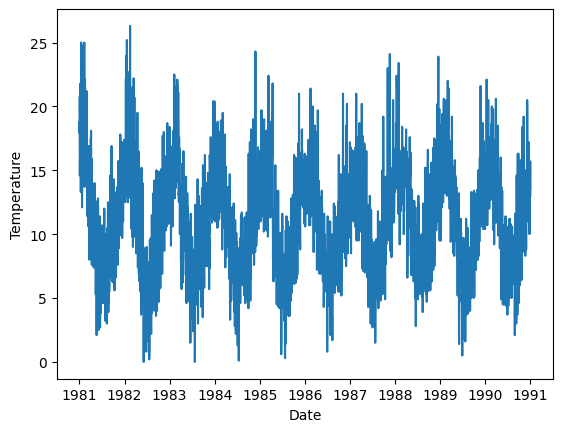

In [ ]:
plt.plot(df['Date'],df['Temp'])
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.show()

In [ ]:
#Moving average
df['MA12']=df['Temp'].rolling(window=12).mean()
df['MA12']

,MA12
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3645,13.875000
3646,13.875000
3647,13.841667
3648,13.716667


In [ ]:
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year
df.head()

,Date,Temp,MA12,Month,Year
0,1981-01-01,20.7,NaN,1,1981
1,1981-01-02,17.9,NaN,1,1981
2,1981-01-03,18.8,NaN,1,1981
3,1981-01-04,14.6,NaN,1,1981
4,1981-01-05,15.8,NaN,1,1981


In [ ]:
df['Series']=np.arange(1,len(df)+1)
df.head()

,Date,Temp,MA12,Month,Year,Series
0,1981-01-01,20.7,NaN,1,1981,1
1,1981-01-02,17.9,NaN,1,1981,2
2,1981-01-03,18.8,NaN,1,1981,3
3,1981-01-04,14.6,NaN,1,1981,4
4,1981-01-05,15.8,NaN,1,1981,5


In [ ]:
dataset_model=df[['Series','Year','Month','Temp']]
dataset_model.head()

,Series,Year,Month,Temp
0,1,1981,1,20.7
1,2,1981,1,17.9
2,3,1981,1,18.8
3,4,1981,1,14.6
4,5,1981,1,15.8


In [ ]:
#Define Independent and depedent model
X=dataset_model[['Series','Year','Month']]
y=dataset_model['Temp']
#

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)
#

In [ ]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=regressor.predict(X_test)
y_pred

array([11.01742726, 10.92188266, 10.3692036 , 10.50874931, 13.04555581,
        9.64879983, 12.45439817, 12.22732576,  9.45602476,  9.96122942,
       12.74728118, 12.24075401, 11.23490805,  9.90380006, 11.84273479,
       12.83551585, 12.23020324, 11.57910211, 12.78096397, 10.57636608,
       12.1782964 , 12.73444874, 10.57672944, 11.8260657 , 12.72869377,
        9.76425435, 11.18419282, 11.59024868, 10.89071399,  9.52076405,
       11.22052064, 12.59490303,  9.66606472, 10.31848837, 11.52203611,
       11.77703634,  9.74758526, 11.0873257 , 12.85853571,  9.70394751,
       10.94394335, 12.8791536 , 12.0785518 , 10.4118822 ,  9.47233049,
       11.57490211, 10.3121376 , 10.68798396,  9.36203513, 13.15489202,
        9.50062167, 11.53354604,  9.96853935, 12.60449464, 11.82414738,
       11.16405044, 12.39349552,  9.71582079, 12.49228095, 10.72011179,
       11.33524845, 11.33812594, 11.3432851 , 11.84081647, 10.70919766,
       10.37843186, 10.62671796,  9.68177465,  9.70778415, 11.82

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.0738058012705125

In [ ]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)


17.0425341003193

In [ ]:
sorted_index=np.argsort(X_test[:0])
plt.plot(X_test[sorted_index],y_test[soted_])
plt.plot(y_test[sorted_index]